# Comparative Analysis of Hyperparameter Optimization Techniques for XGBoost in PM2.5 Prediction
## Using CPCB India Air Quality Data (city_day.csv)

**Dataset:** Air Quality Data in India — Kaggle/CPCB  
**Target:** PM2.5  
**Libraries:** pandas, numpy, scikit-learn, xgboost, optuna, matplotlib, seaborn


In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform, randint
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import time, os

RANDOM_STATE = 42
TEST_SIZE    = 0.20
DATA_PATH    = '../data/city_day.csv'   # Update path as needed
FIGURES_DIR  = '../figures'
RESULTS_DIR  = '../results'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

FEATURE_COLS = ['PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Xylene','City']
TARGET_COL   = 'PM2.5'
plt.rcParams.update({'figure.dpi': 300, 'font.size': 11})
print('Imports OK checkmark')


Imports OK checkmark


## Step 1 — Data Loading

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()


Shape: (29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [3]:
print('Columns:', df.columns.tolist())
print()
print(df.dtypes)


Columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object


## Step 2 — Exploratory Data Analysis

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)


,Missing Count,Missing %
Xylene,18109,61.32
PM10,11140,37.72
NH3,10328,34.97
Toluene,8041,27.23
Benzene,5623,19.04
AQI,4681,15.85
AQI_Bucket,4681,15.85
PM2.5,4598,15.57
NOx,4185,14.17
O3,4022,13.62


In [5]:
df.describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
PM2.5,24933.0,67.451,64.661,0.04,28.820,48.57,80.590,949.99
PM10,18391.0,118.127,90.605,0.01,56.255,95.68,149.745,1000.00
NO,25949.0,17.575,22.786,0.02,5.630,9.89,19.950,390.68
NO2,25946.0,28.561,24.475,0.01,11.750,21.69,37.620,362.21
NOx,25346.0,32.309,31.646,0.00,12.820,23.52,40.128,467.63
NH3,19203.0,23.483,25.684,0.01,8.580,15.85,30.020,352.89
CO,27472.0,2.249,6.963,0.00,0.510,0.89,1.450,175.81
SO2,25677.0,14.532,18.134,0.01,5.670,9.16,15.220,193.86
O3,25509.0,34.491,21.695,0.01,18.860,30.84,45.570,257.73
Benzene,23908.0,3.281,15.811,0.00,0.120,1.07,3.080,455.03


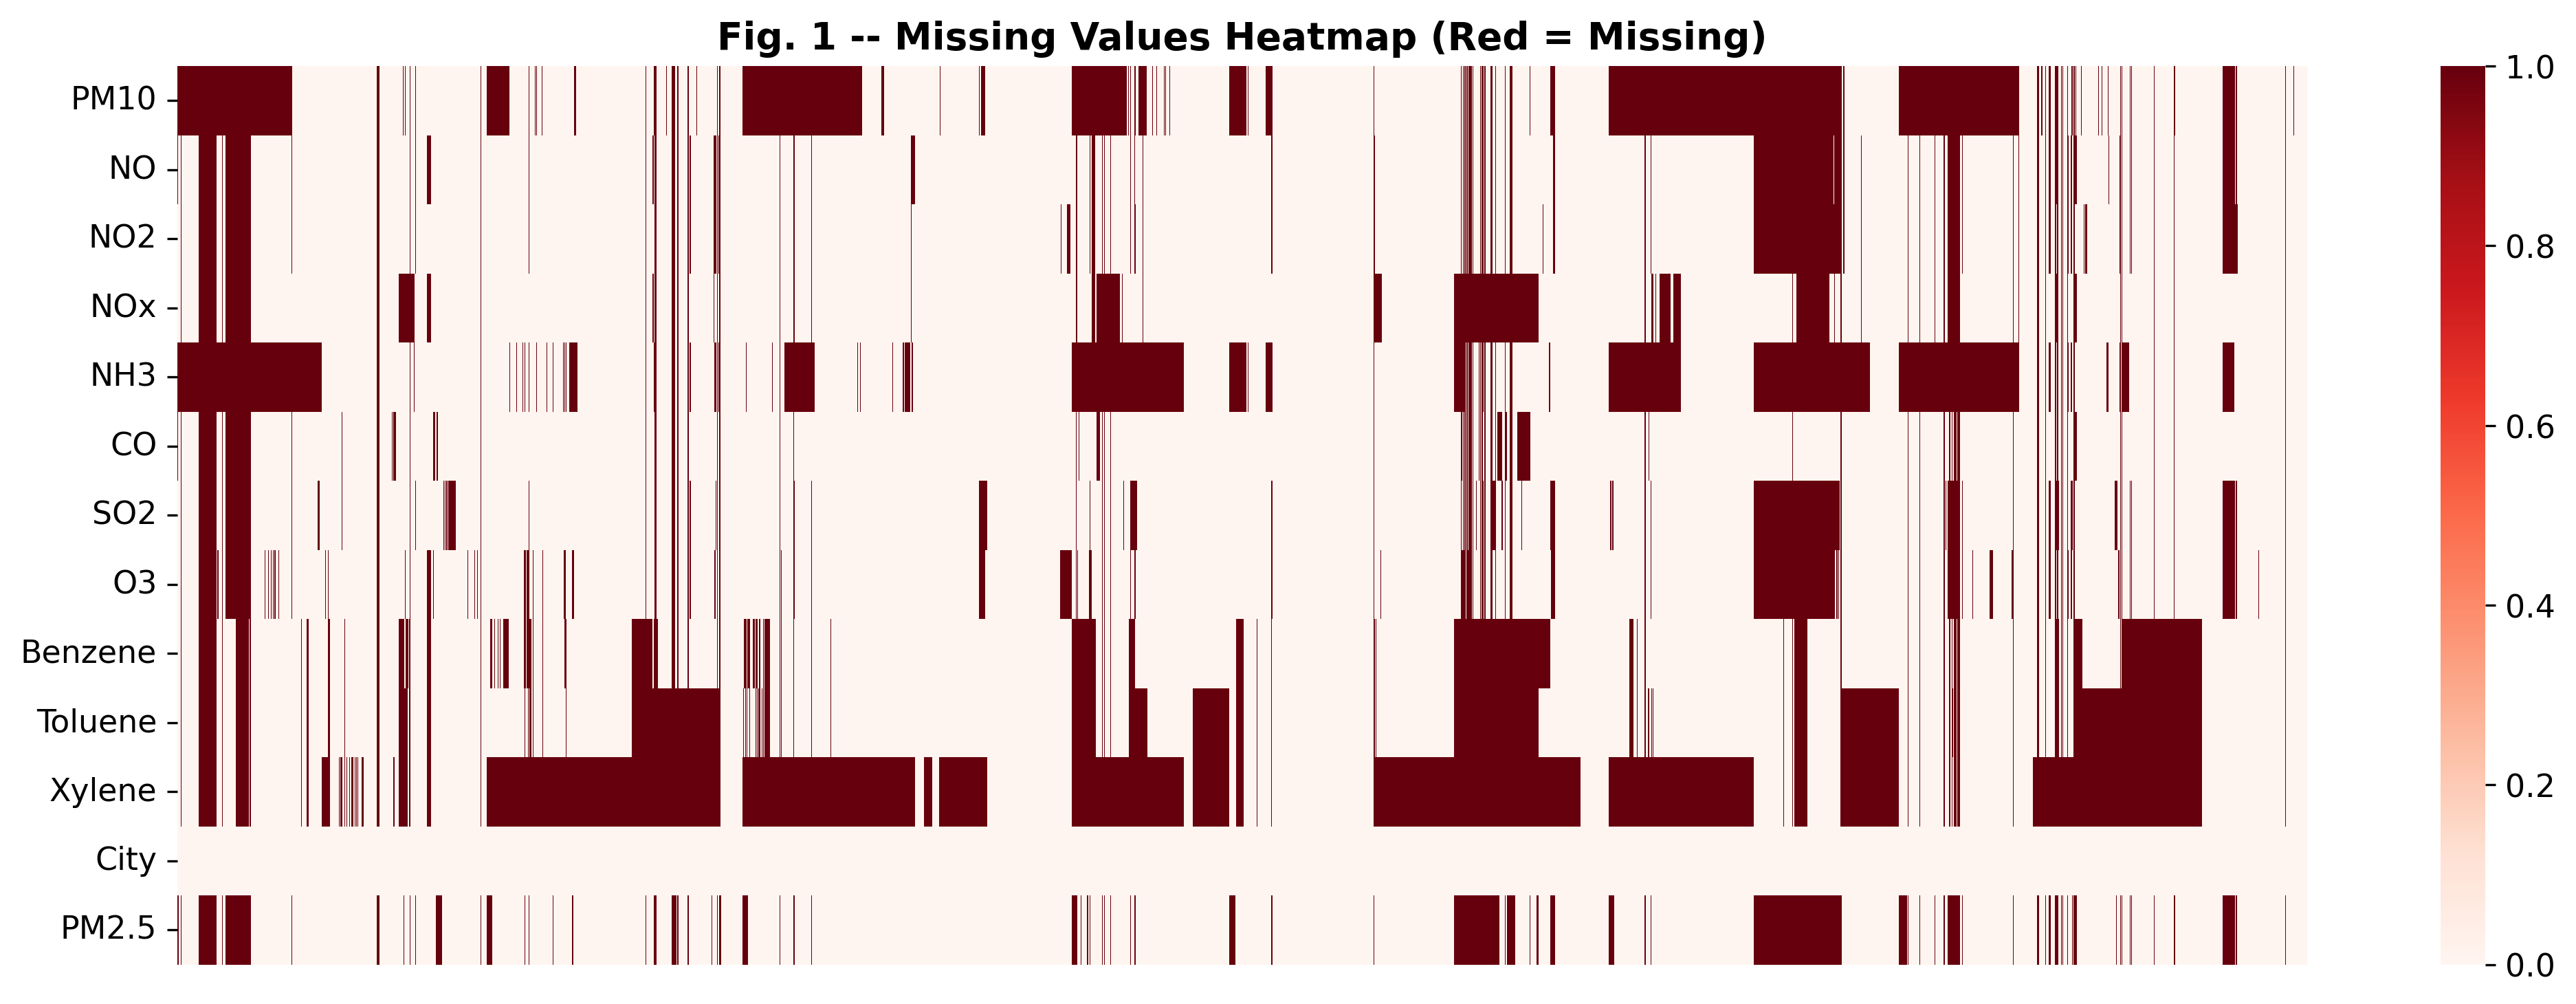

In [6]:
# Fig 1 -- Missing Values Heatmap
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df[FEATURE_COLS + [TARGET_COL]].isnull().astype(int).T,
            cmap='Reds', cbar=True, xticklabels=False, ax=ax)
ax.set_title('Fig. 1 -- Missing Values Heatmap (Red = Missing)', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/fig1_missing_heatmap.png'); plt.show()


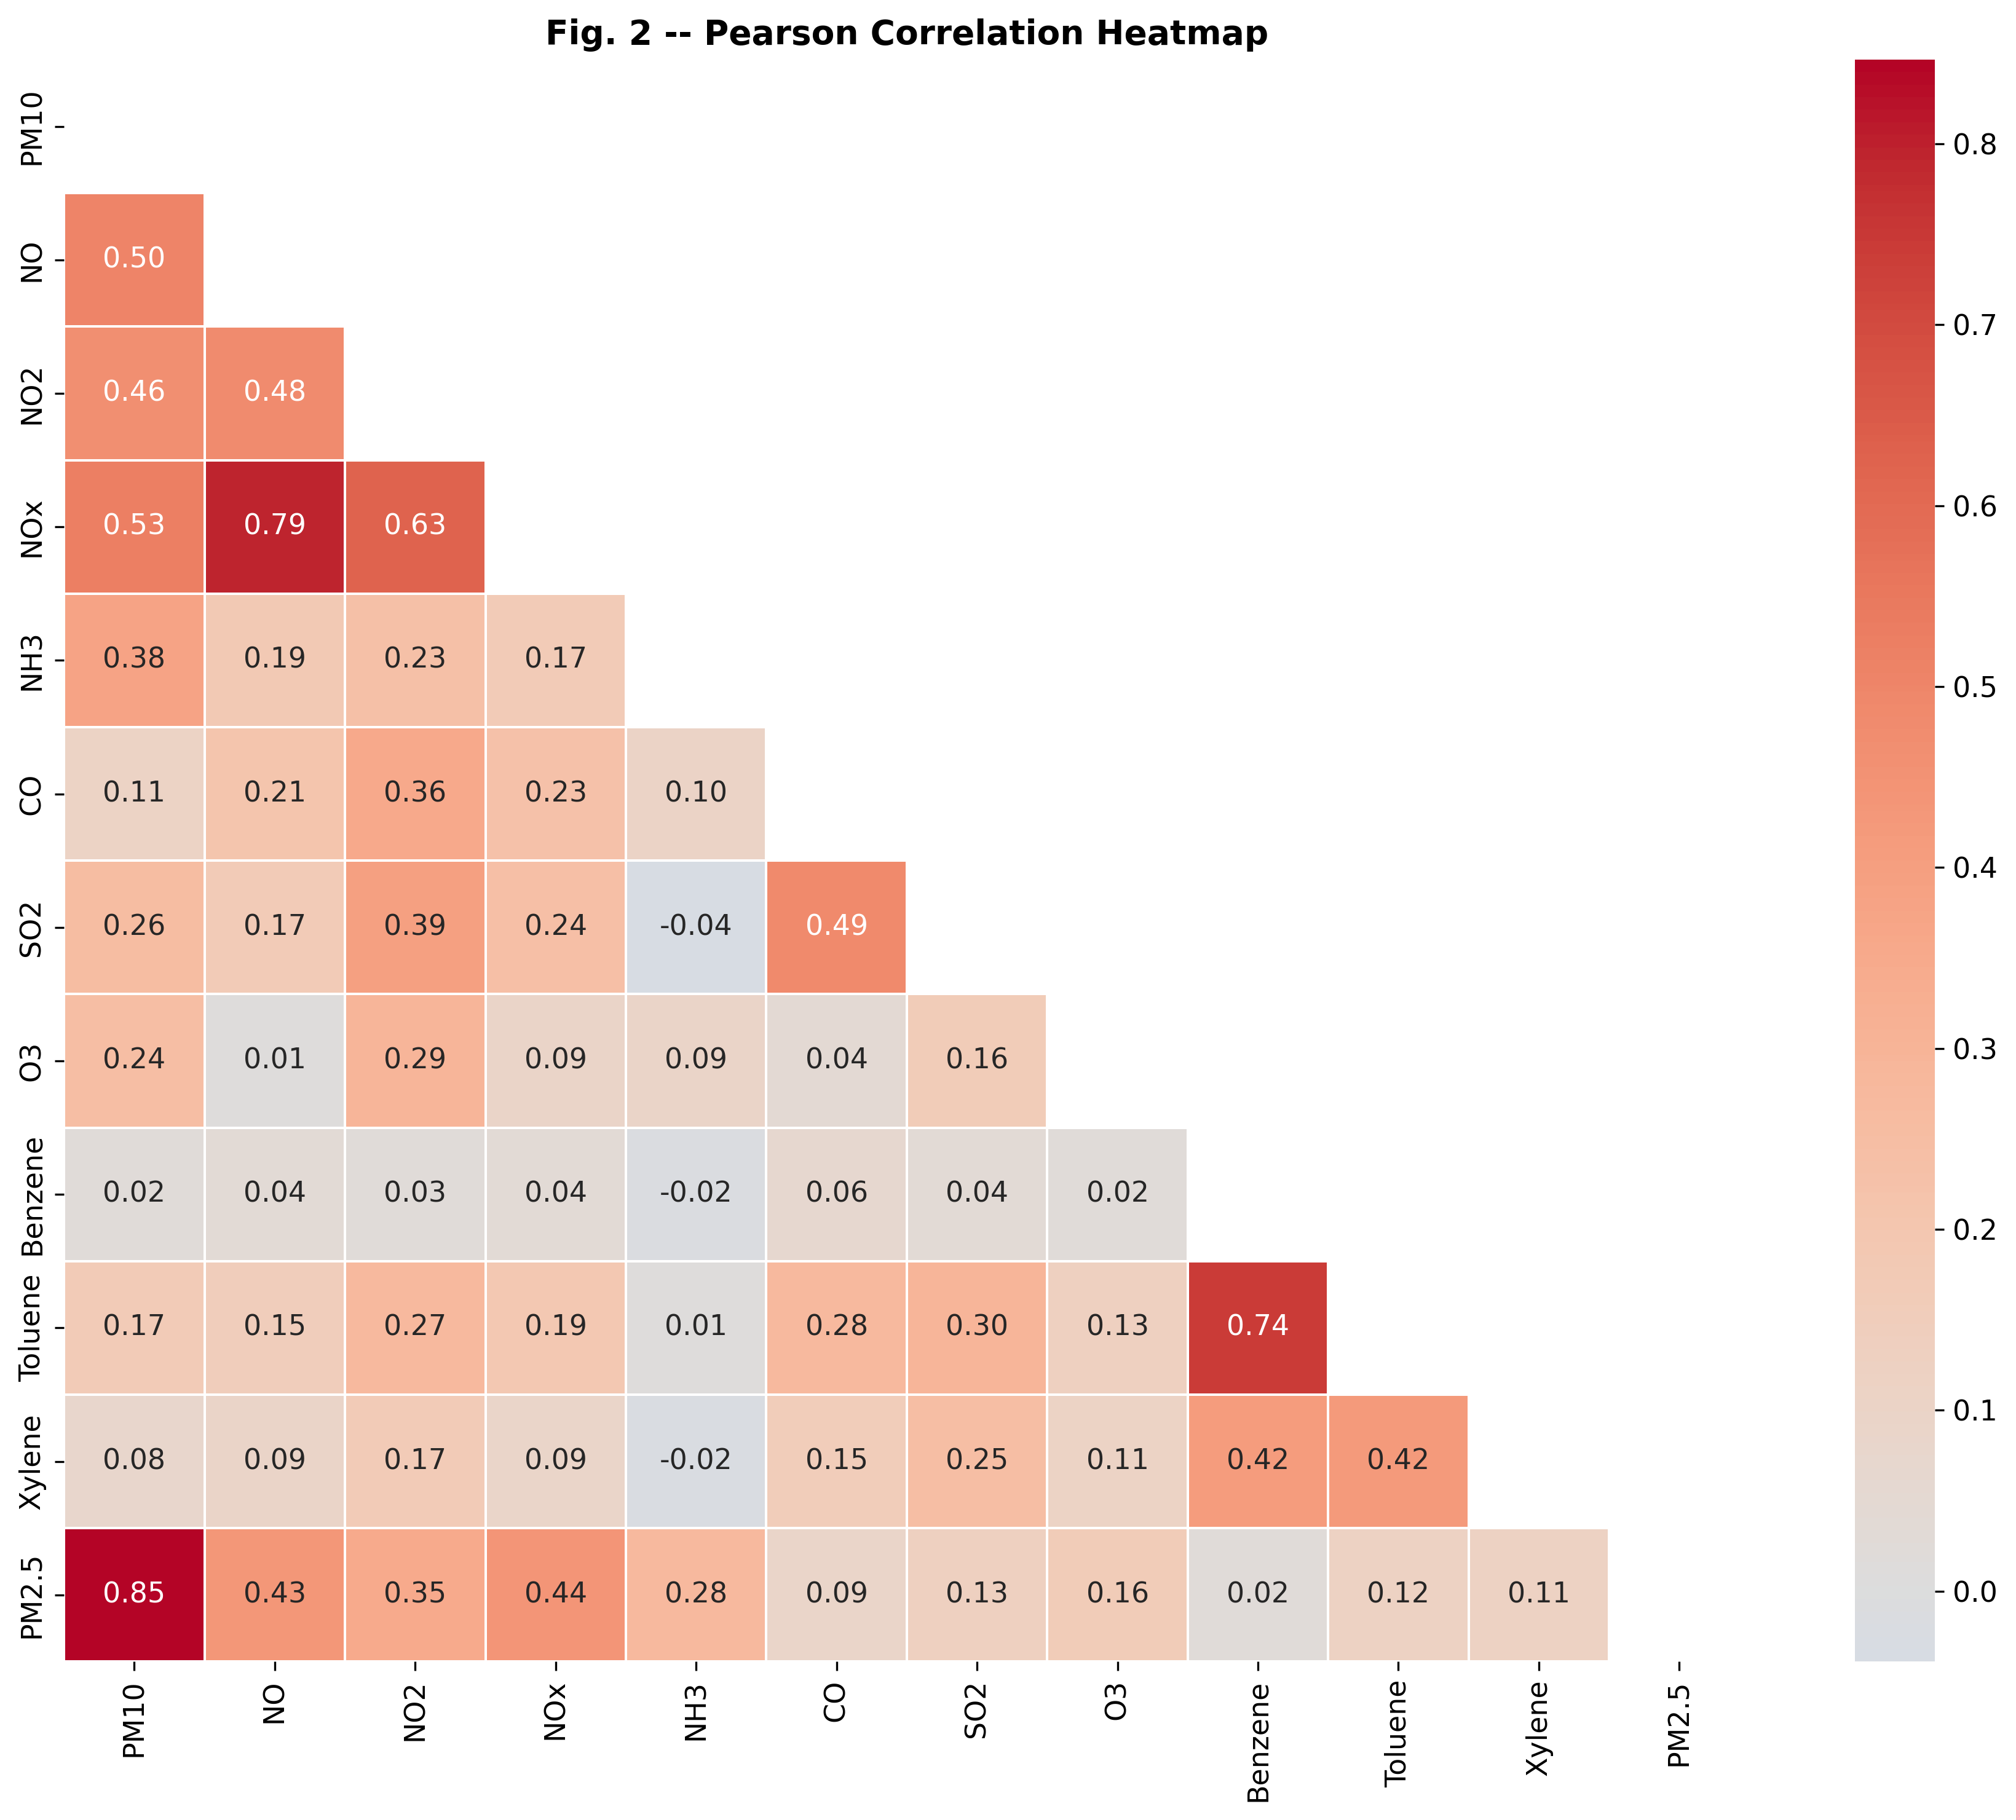

In [7]:
# Fig 2 -- Correlation Heatmap
numeric_cols = [c for c in FEATURE_COLS if c != 'City'] + [TARGET_COL]
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Fig. 2 -- Pearson Correlation Heatmap', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/fig2_correlation_heatmap.png'); plt.show()


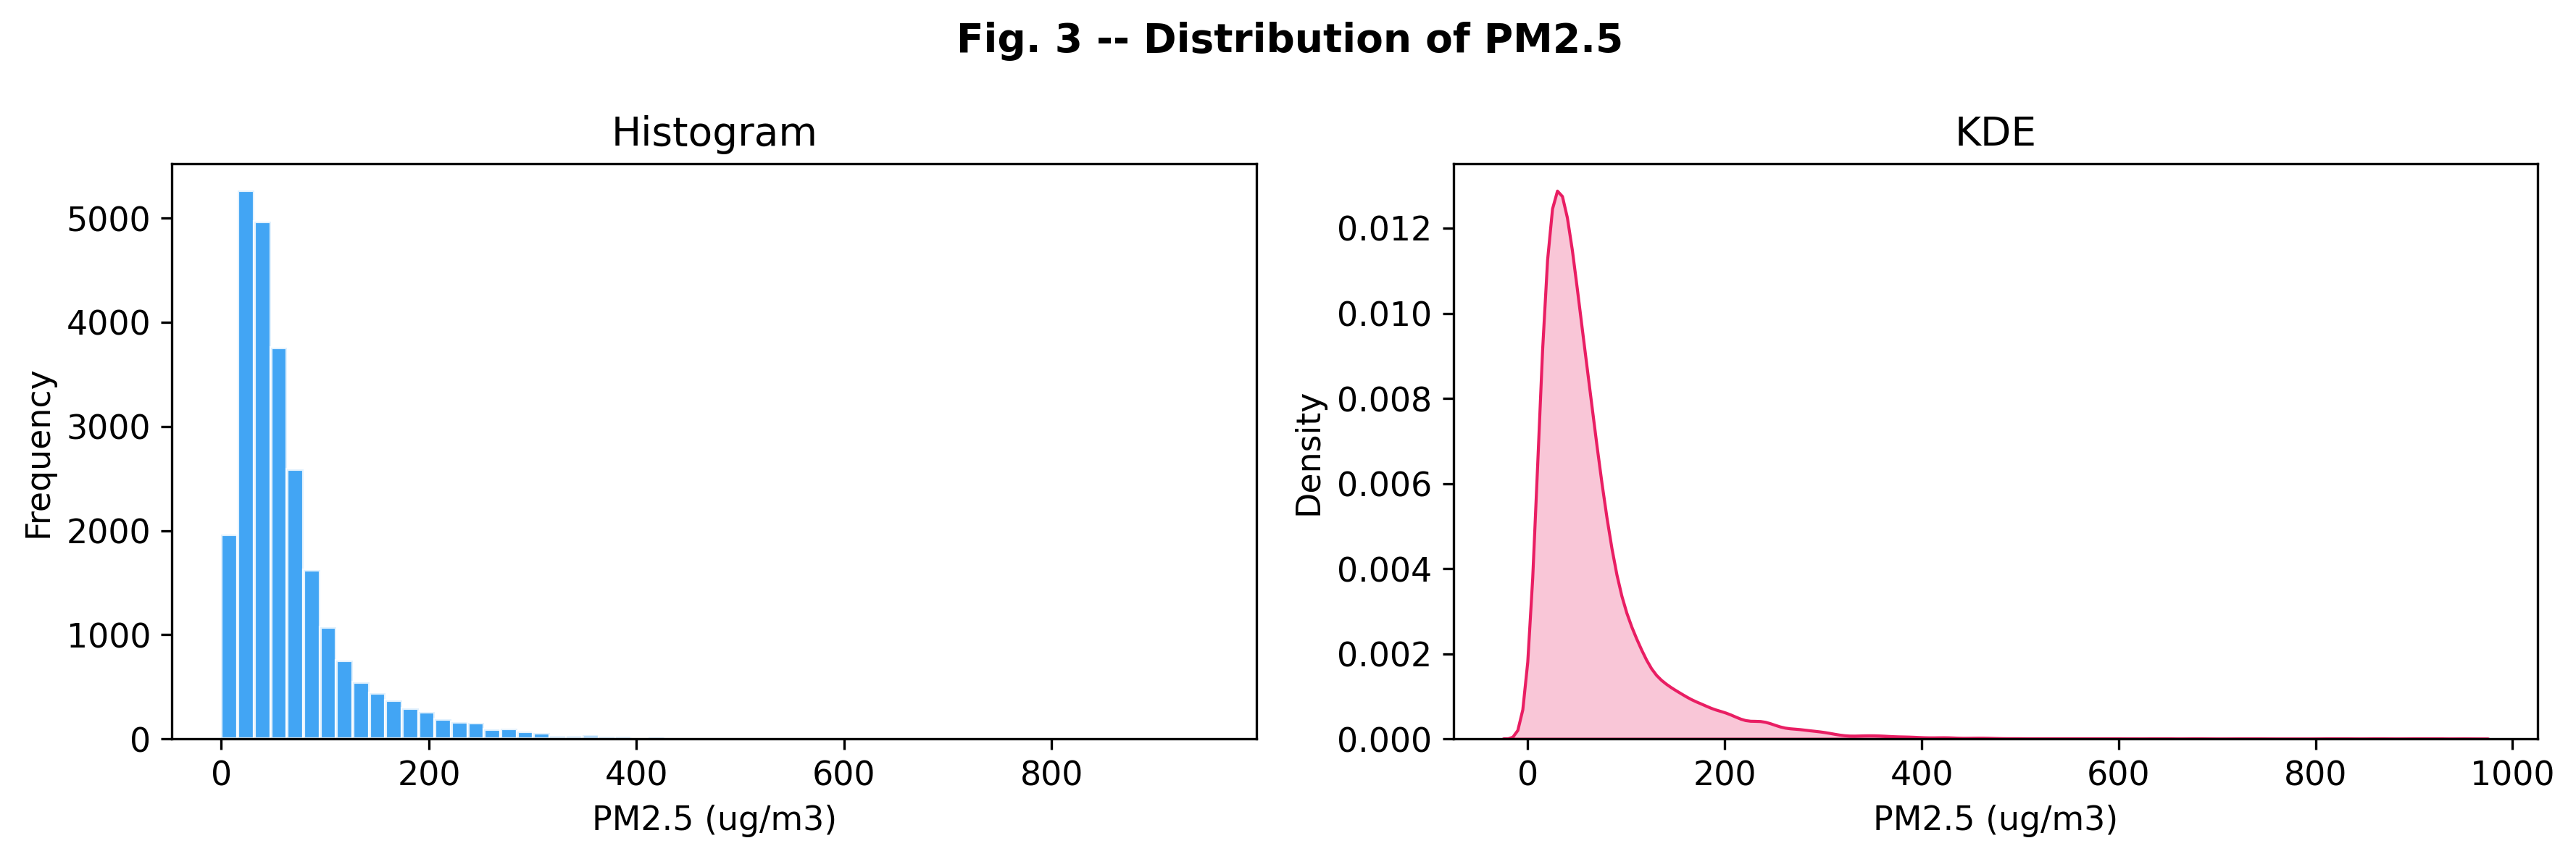

In [8]:
# Fig 3 -- PM2.5 Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pm25 = df[TARGET_COL].dropna()
axes[0].hist(pm25, bins=60, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set(xlabel='PM2.5 (ug/m3)', ylabel='Frequency', title='Histogram')
sns.kdeplot(pm25, ax=axes[1], fill=True, color='#E91E63')
axes[1].set(xlabel='PM2.5 (ug/m3)', title='KDE')
fig.suptitle('Fig. 3 -- Distribution of PM2.5', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/fig3_pm25_distribution.png'); plt.show()


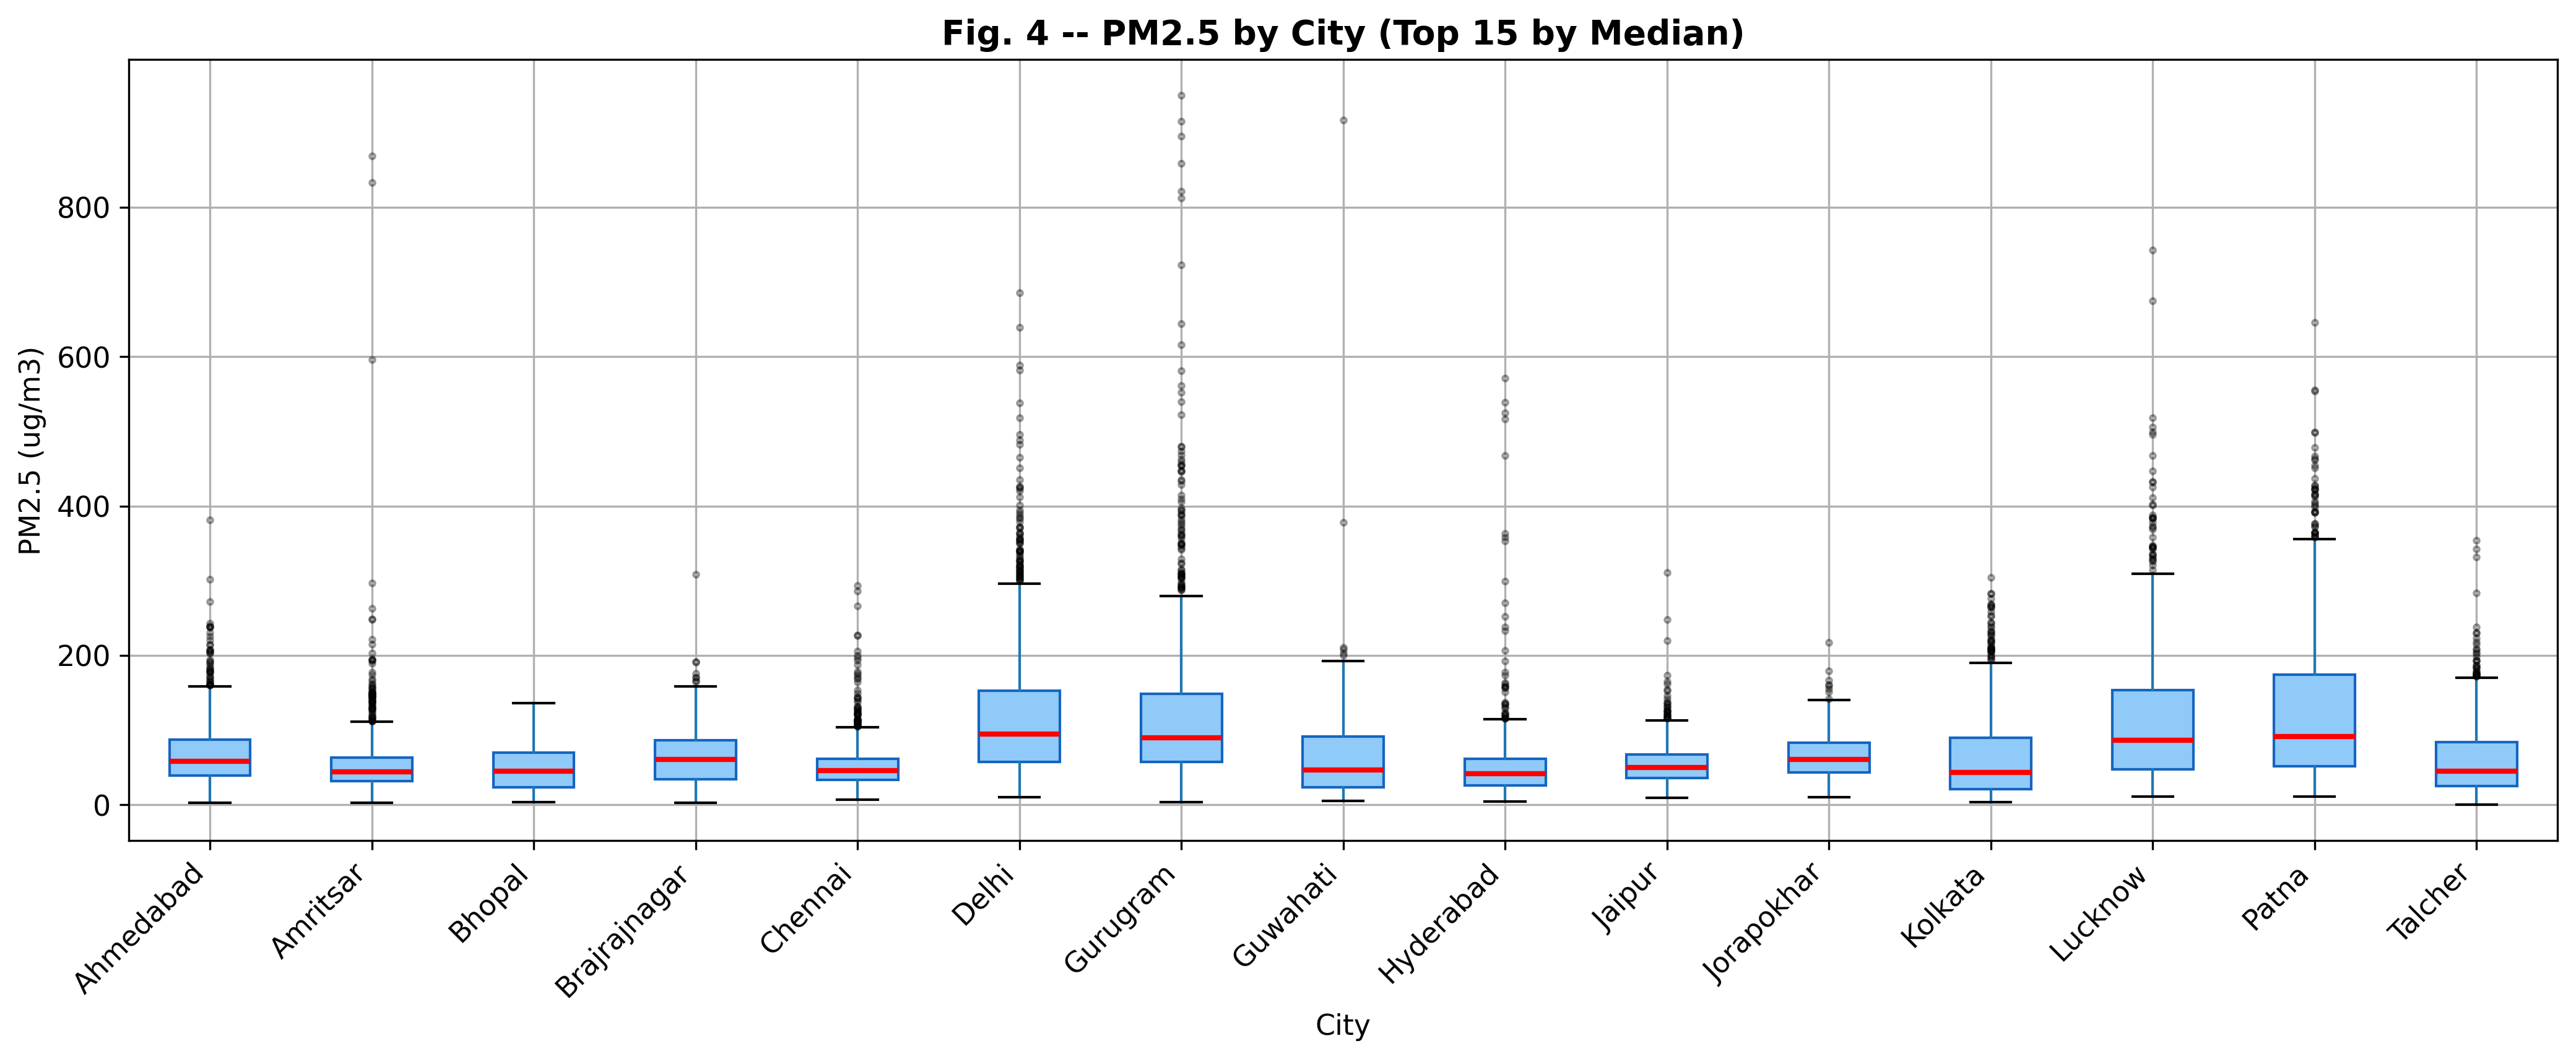

In [9]:
# Fig 4 -- PM2.5 by City
top_cities = df.groupby('City')[TARGET_COL].median().nlargest(15).index
city_sub = df[df['City'].isin(top_cities)]
fig, ax = plt.subplots(figsize=(14, 6))
city_sub.boxplot(column=TARGET_COL, by='City', ax=ax, patch_artist=True,
    boxprops=dict(facecolor='#90CAF9', color='#1565C0'),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.4))
ax.set_title('Fig. 4 -- PM2.5 by City (Top 15 by Median)', fontweight='bold')
ax.set_xlabel('City'); ax.set_ylabel('PM2.5 (ug/m3)')
plt.suptitle(''); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/fig4_pm25_by_city.png'); plt.show()


## Step 3 — Data Cleaning
- Drop `AQI` and `AQI_Bucket` (data leakage)
- Encode `City` with LabelEncoder
- Drop rows where PM2.5 is missing
- Impute feature NaNs with column median


In [10]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.drop(columns=['AQI','AQI_Bucket','Date'], inplace=True, errors='ignore')
le = LabelEncoder()
df['City'] = le.fit_transform(df['City'].astype(str))
before = len(df)
df.dropna(subset=[TARGET_COL], inplace=True)
print(f'Dropped {before-len(df)} rows with missing PM2.5')
for col in [c for c in FEATURE_COLS if c != 'City']:
    if col in df.columns: df[col].fillna(df[col].median(), inplace=True)
print('Final shape:', df.shape)
df[FEATURE_COLS + [TARGET_COL]].isnull().sum()


Dropped 4598 rows with missing PM2.5
Final shape: (24933, 13)


PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
Xylene     0
City       0
PM2.5      0
dtype: int64

## Step 4 — Feature Selection & Train/Test Split

In [11]:
X = df[FEATURE_COLS]; y = df[TARGET_COL]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')


Train: 19946  |  Test: 4987


## Step 5 — Baseline XGBoost Model

In [12]:
def evaluate(y_true, y_pred, label='Model'):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'  [{label}]  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}')
    return {'Model': label, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

t0 = time.time()
baseline = xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
baseline.fit(X_train, y_train)
m_base = evaluate(y_test, baseline.predict(X_test), 'Baseline XGBoost')
m_base['Time(s)'] = round(time.time()-t0, 2)


  [Baseline XGBoost]  RMSE=35.6230  MAE=17.4934  R2=0.7038


## Step 6 — Hyperparameter Optimization
### Method 1: GridSearchCV

In [13]:
grid_params = {
    'learning_rate'   : [0.05, 0.1],
    'max_depth'       : [3, 5],
    'n_estimators'    : [100, 200],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
t0 = time.time()
gs = GridSearchCV(xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
                  param_grid=grid_params, scoring='neg_root_mean_squared_error', cv=3, n_jobs=-1)
gs.fit(X_train, y_train)
print('Best params:', gs.best_params_)
m_grid = evaluate(y_test, gs.best_estimator_.predict(X_test), 'GridSearchCV')
m_grid['Time(s)'] = round(time.time()-t0, 2)


Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
  [GridSearchCV]  RMSE=35.0883  MAE=17.4038  R2=0.7126


### Method 2: RandomizedSearchCV

In [14]:
param_dist = {
    'learning_rate'   : uniform(0.01, 0.29),
    'max_depth'       : randint(3, 10),
    'n_estimators'    : randint(50, 401),
    'subsample'       : uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
}
t0 = time.time()
rs = RandomizedSearchCV(xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
                        param_distributions=param_dist, n_iter=40,
                        scoring='neg_root_mean_squared_error', cv=3,
                        random_state=RANDOM_STATE, n_jobs=-1)
rs.fit(X_train, y_train)
print('Best params:', rs.best_params_)
m_rand = evaluate(y_test, rs.best_estimator_.predict(X_test), 'RandomizedSearchCV')
m_rand['Time(s)'] = round(time.time()-t0, 2)


Best params: {'colsample_bytree': np.float64(0.8925879806965068), 'learning_rate': np.float64(0.06790539682592432), 'max_depth': 9, 'n_estimators': 293, 'subsample': np.float64(0.7962072844310213)}
  [RandomizedSearchCV]  RMSE=34.1067  MAE=15.5000  R2=0.7285


### Method 3: Bayesian Optimization (Optuna)

In [15]:
optuna_scores = []

def objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int  ('n_estimators',     50, 400),
        'max_depth'       : trial.suggest_int  ('max_depth',         3,   9),
        'learning_rate'   : trial.suggest_float('learning_rate',  0.01, 0.30, log=True),
        'subsample'       : trial.suggest_float('subsample',       0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree',0.5, 1.0),
        'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': 0,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
    optuna_scores.append(rmse); return rmse

t0 = time.time()
study = optuna.create_study(direction='minimize',
                             sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50, show_progress_bar=True)
best_p = {**study.best_params, 'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': 0}
print('Best params:', best_p)
optuna_model = xgb.XGBRegressor(**best_p)
optuna_model.fit(X_train, y_train)
m_optuna = evaluate(y_test, optuna_model.predict(X_test), 'Bayesian (Optuna)')
m_optuna['Time(s)'] = round(time.time()-t0, 2)


  0%|          | 0/50 [00:00<?, ?it/s]

Best params: {'n_estimators': 303, 'max_depth': 9, 'learning_rate': 0.04572748398846477, 'subsample': 0.9037534662937331, 'colsample_bytree': 0.6351462567795371, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
  [Bayesian (Optuna)]  RMSE=33.3905  MAE=15.5399  R2=0.7398


## Step 7 — Results Comparison

In [16]:
results_df = pd.DataFrame([m_base, m_grid, m_rand, m_optuna]).set_index('Model')
results_df.to_csv(f'{RESULTS_DIR}/model_comparison.csv')
results_df.style.highlight_min(subset=['RMSE','MAE'], color='#c8e6c9')\
               .highlight_max(subset=['R2'],           color='#c8e6c9')\
               .format(precision=4)


,RMSE,MAE,R2,Time(s)
Model,,,,
Baseline XGBoost,35.6230,17.4934,0.7038,2.1100
GridSearchCV,35.0883,17.4038,0.7126,30.1200
RandomizedSearchCV,34.1067,15.5000,0.7285,83.1800
Bayesian (Optuna),33.3905,15.5399,0.7398,91.2000


## Step 8 — Visualizations

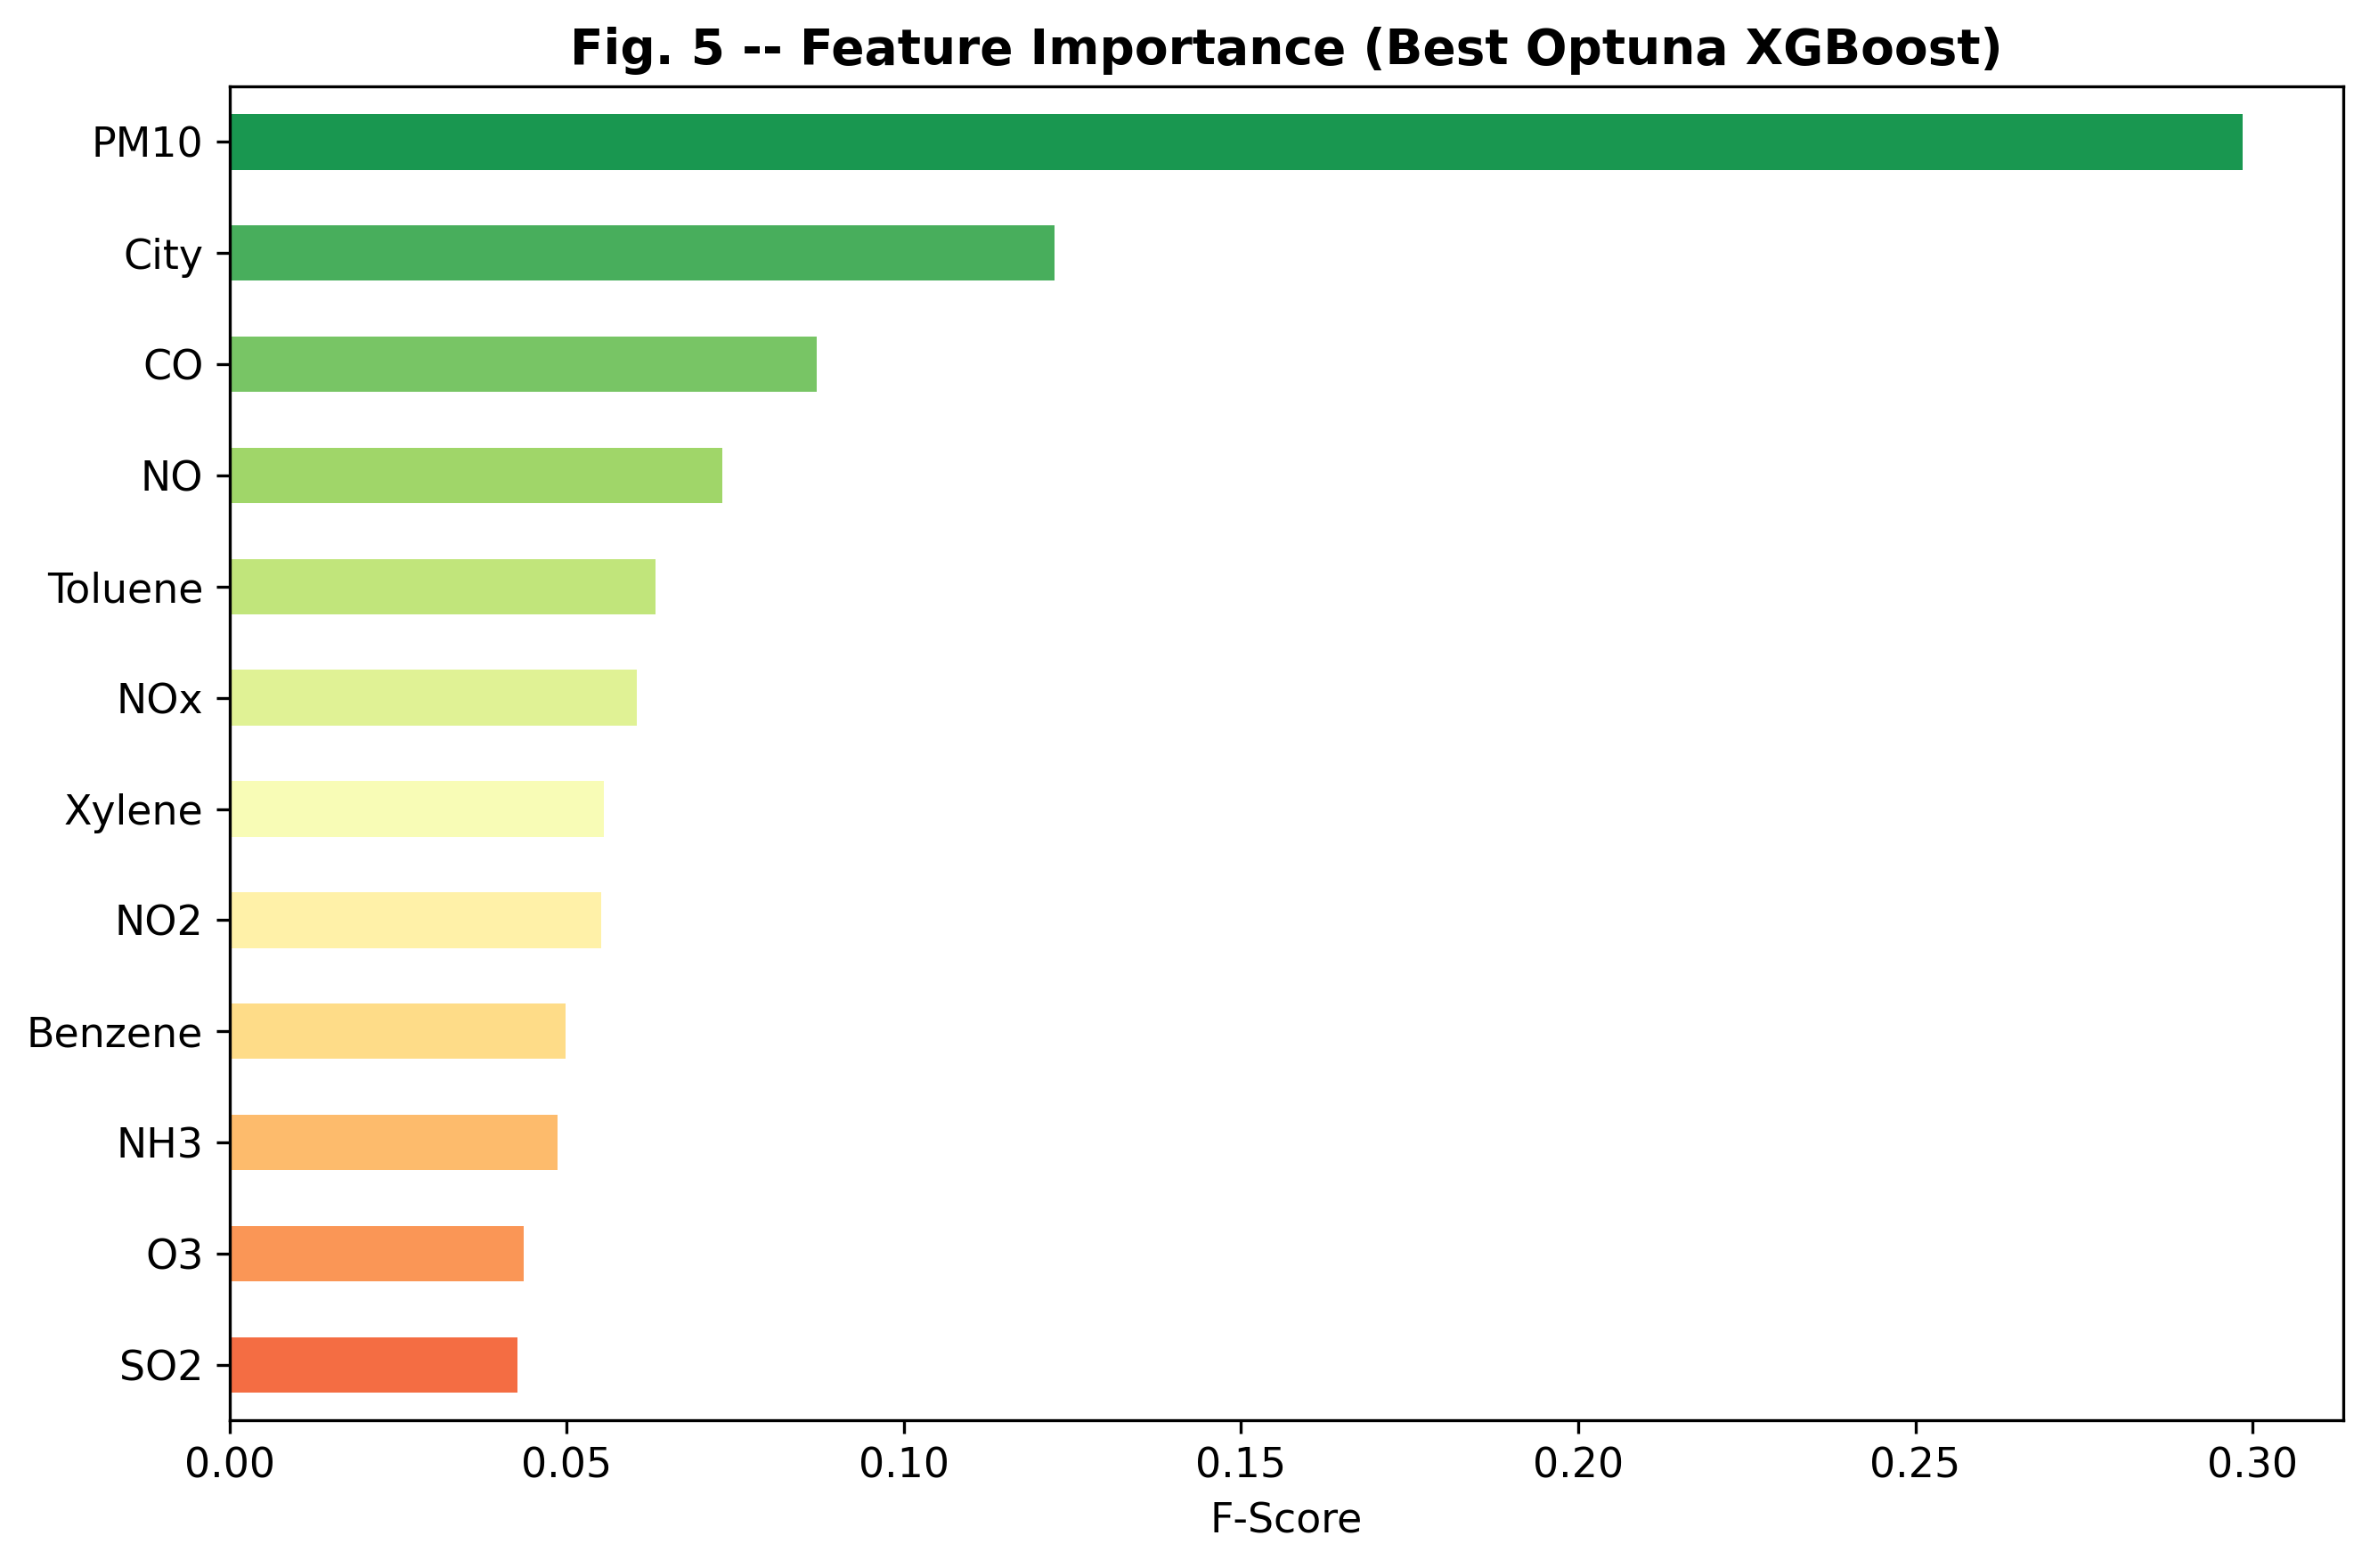

In [17]:
# Fig 5 -- Feature Importance
imp = pd.Series(optuna_model.feature_importances_, index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(imp)))
imp.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Fig. 5 -- Feature Importance (Best Optuna XGBoost)', fontweight='bold')
ax.set_xlabel('F-Score')
plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/fig5_feature_importance.png'); plt.show()


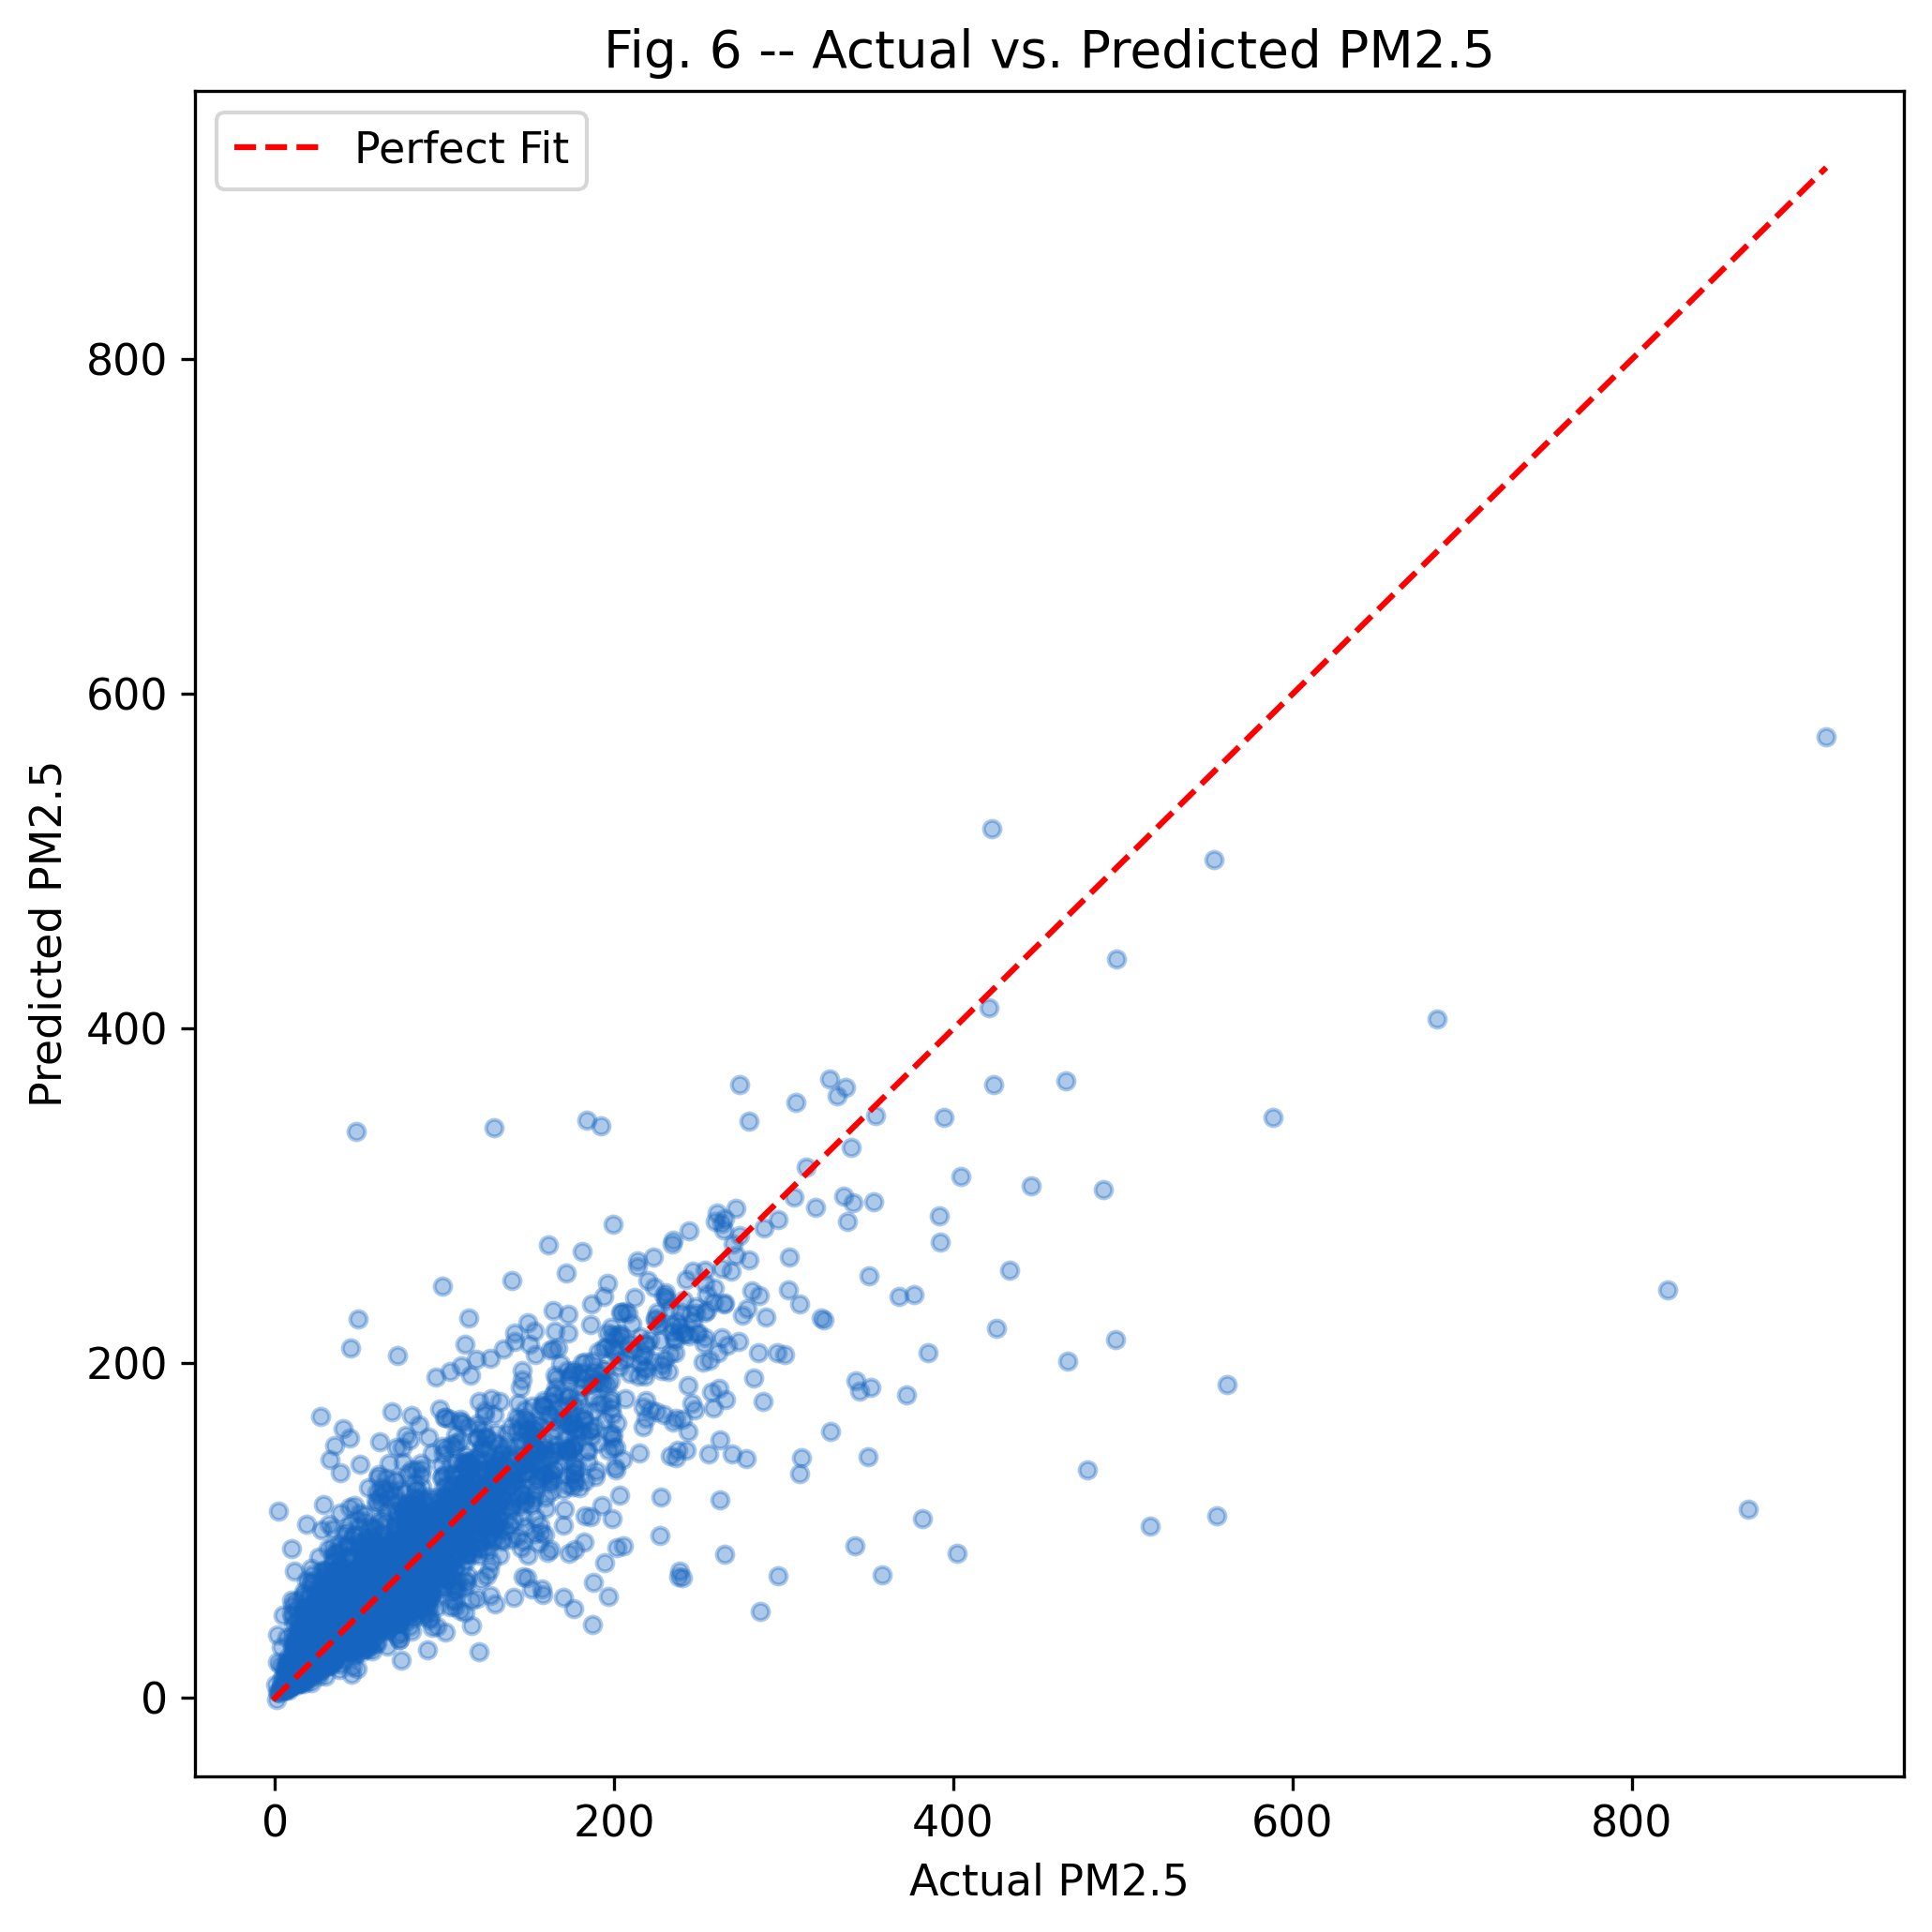

In [18]:
# Fig 6 -- Actual vs Predicted
y_pred_opt = optuna_model.predict(X_test)
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_opt, alpha=0.35, s=18, color='#1565C0')
lims = [min(y_test.min(), y_pred_opt.min()), max(y_test.max(), y_pred_opt.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect Fit')
ax.set(xlabel='Actual PM2.5', ylabel='Predicted PM2.5',
       title='Fig. 6 -- Actual vs. Predicted PM2.5')
ax.legend(); plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig6_actual_vs_predicted.png'); plt.show()


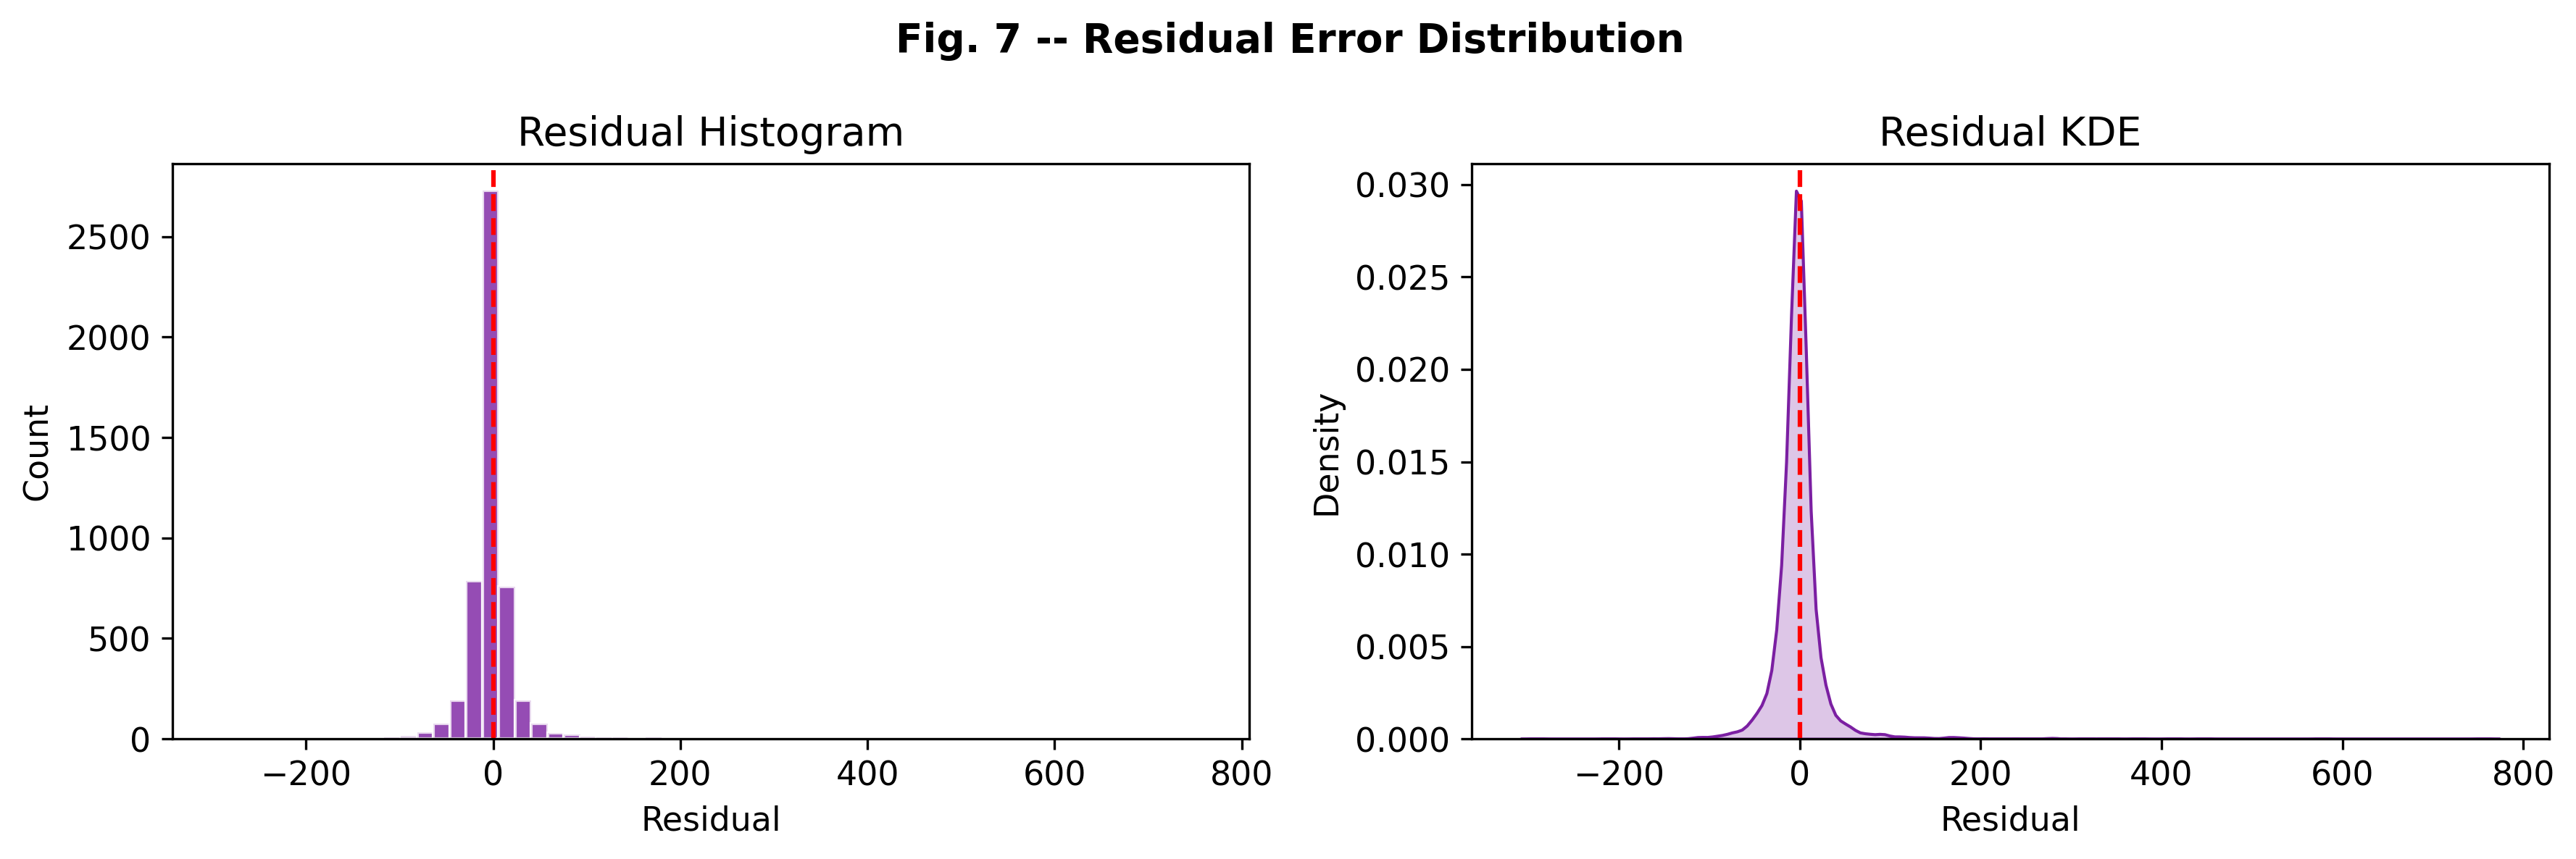

In [19]:
# Fig 7 -- Residuals
residuals = y_test.values - y_pred_opt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(residuals, bins=60, color='#7B1FA2', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set(xlabel='Residual', ylabel='Count', title='Residual Histogram')
sns.kdeplot(residuals, ax=axes[1], fill=True, color='#7B1FA2')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set(xlabel='Residual', title='Residual KDE')
fig.suptitle('Fig. 7 -- Residual Error Distribution', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/fig7_residuals.png'); plt.show()


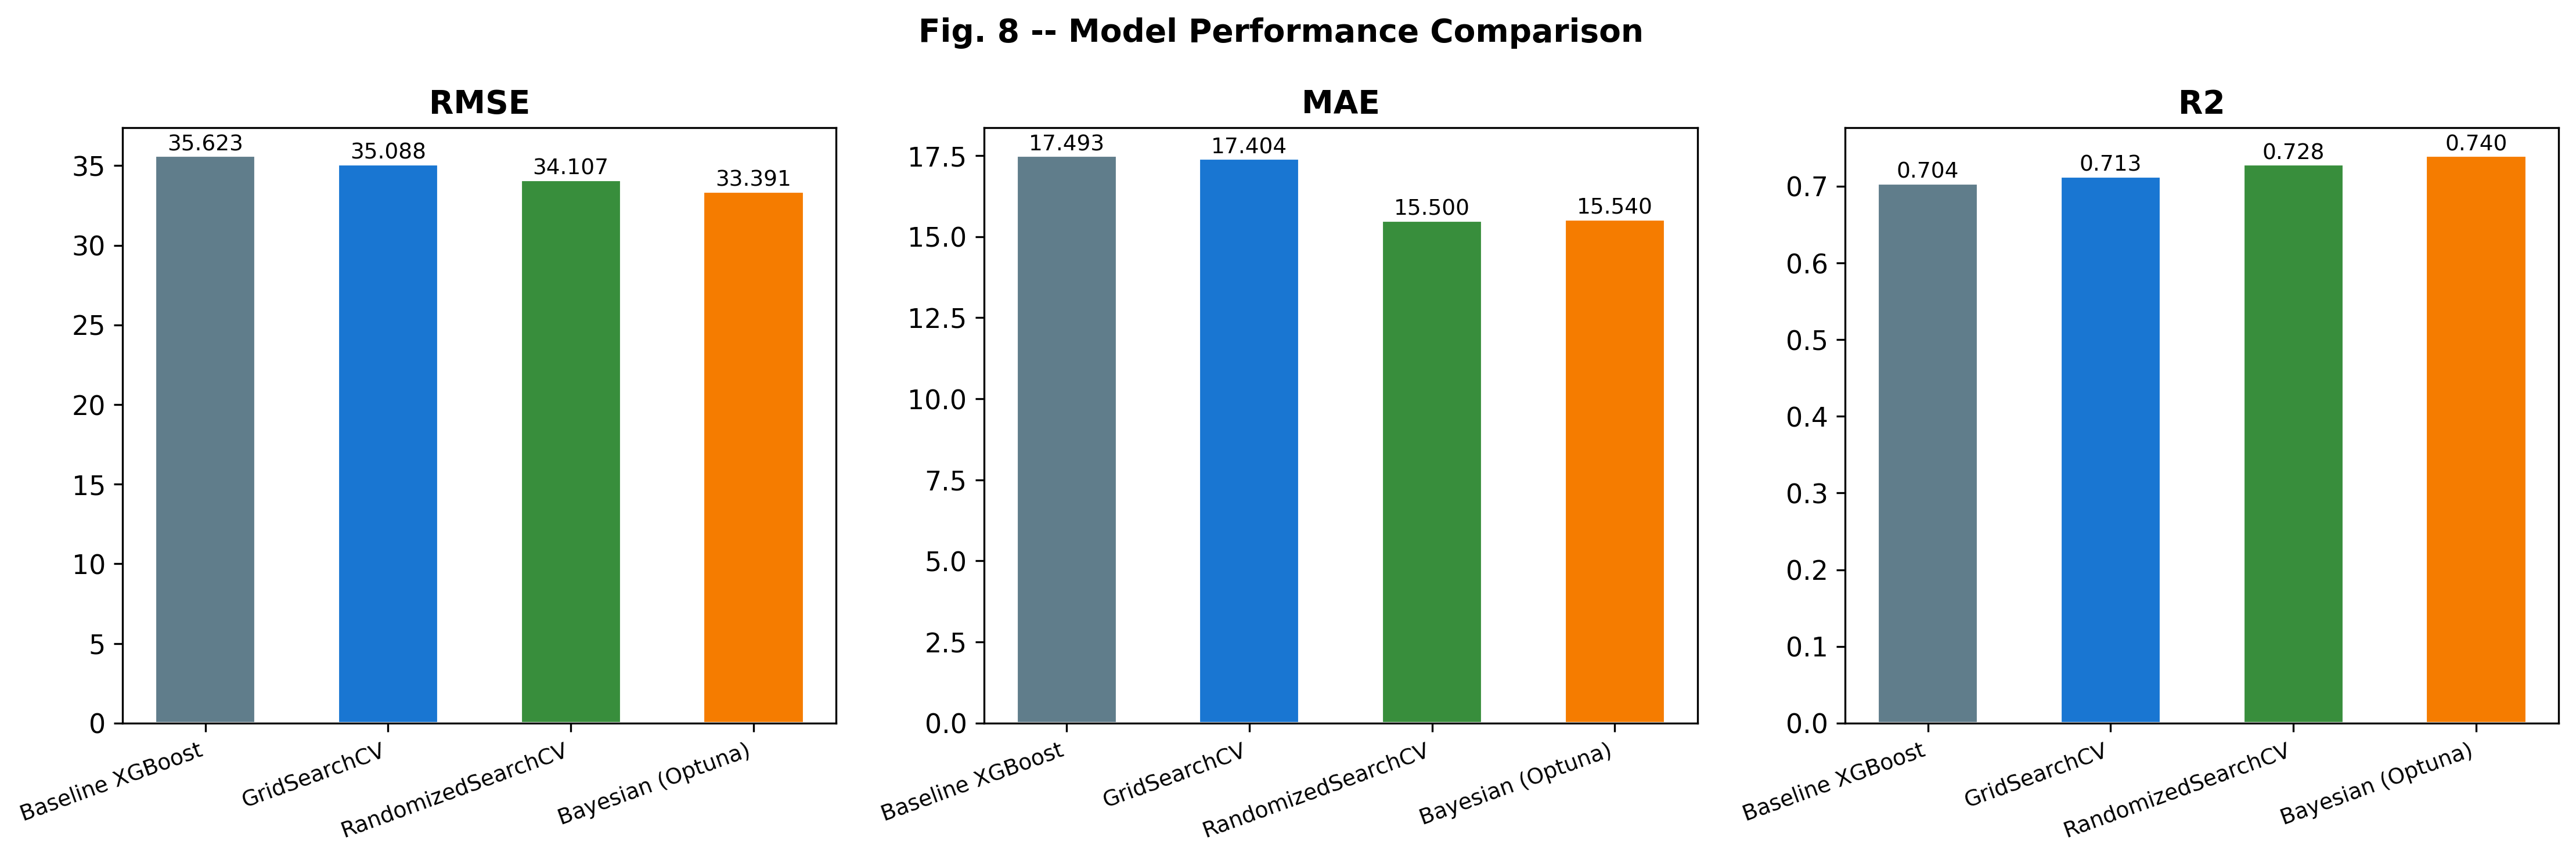

In [20]:
# Fig 8 -- Model Comparison Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bar_colors = ['#607D8B','#1976D2','#388E3C','#F57C00']
x = np.arange(len(results_df))
for i, metric in enumerate(['RMSE','MAE','R2']):
    vals = results_df[metric].values
    bars = axes[i].bar(x, vals, color=bar_colors, width=0.55, edgecolor='white')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(results_df.index, rotation=20, ha='right', fontsize=9)
    axes[i].set_title(metric, fontweight='bold')
    for b, v in zip(bars, vals):
        axes[i].text(b.get_x()+b.get_width()/2, b.get_height()+max(vals)*0.01,
                     f'{v:.3f}', ha='center', fontsize=9)
fig.suptitle('Fig. 8 -- Model Performance Comparison', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/fig8_model_comparison.png'); plt.show()


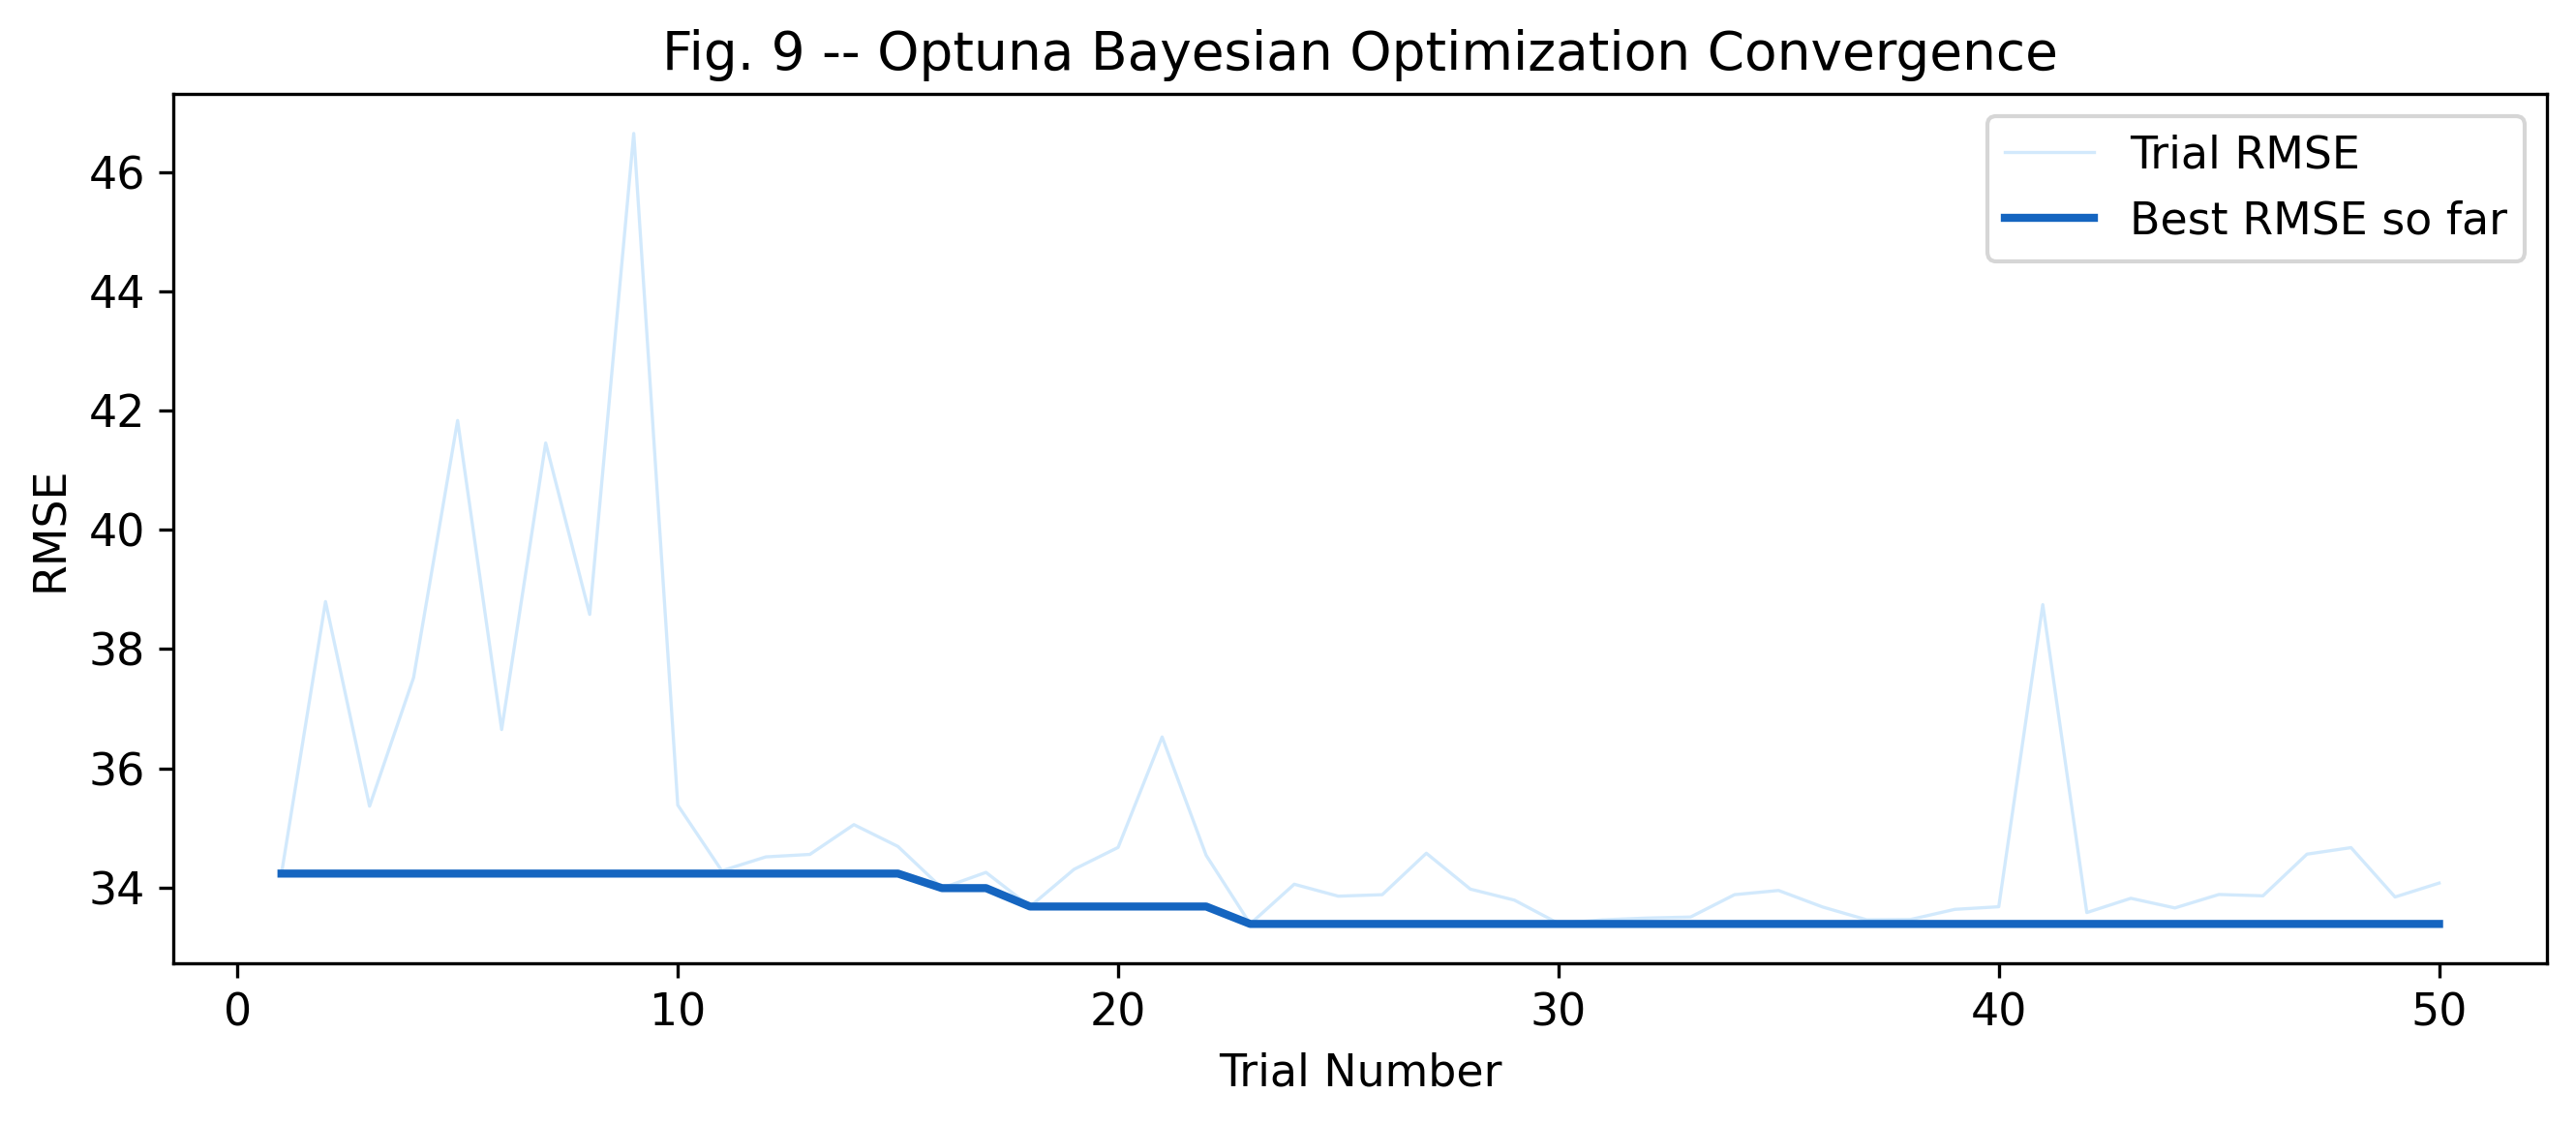

In [21]:
# Fig 9 -- Optuna Convergence
best_so_far = np.minimum.accumulate(optuna_scores)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(optuna_scores)+1), optuna_scores,
        alpha=0.4, color='#90CAF9', lw=0.8, label='Trial RMSE')
ax.plot(range(1, len(best_so_far)+1), best_so_far,
        color='#1565C0', lw=2, label='Best RMSE so far')
ax.set(xlabel='Trial Number', ylabel='RMSE',
       title='Fig. 9 -- Optuna Bayesian Optimization Convergence')
ax.legend(); plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig9_optuna_convergence.png'); plt.show()
